# Case Study: Data-driven Simulation 

In [ ]:
import pymanopt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300        
plt.rcParams["savefig.dpi"] = 300       
import os
from flag import *
from utils import *
np.random.seed(42)

T_SIM = 300
T_SWITCH = 100
T_INI = 4
T_F = 4
L = T_INI + T_F
m = 1
n = 1

def system1(y1, y0, u1, u0, noise):
    # y = 1.2 * y1 - 0.32 * y0 + 0.50 * u1 + 0.10 * u0 + noise
    y = 0.3 * y1 - 0.02 * y0 + 0.5 * u1 + 0.1 * u0 + noise

    a1, a2 = 0.3, -0.02
    b0, b1 = 0.6, 0.2
    y = a1*y1 + a2*y0 + b0*u1 + b1*u0 + noise

    return np.asarray(y).reshape(-1)[0]

def system2(y2, y1, y0, u2, u1, u0, noise):
    # y = 2.1 * y2 - 1.43 * y1 + 0.315 * y0 + \
    #     0.60 * u2 + 0.20 * u1 + 0.05 * u0 + noise
    y = 2.2 * y2 - 1.57 * y1 + 0.36 * y0 \
        + 0.6 * u2 + 0.2 * u1 + 0.05 * u0 + noise

    a1, a2, a3 = 1.5, -0.74, 0.12
    b0, b1, b2 = 0.6, 0.2, 0.05
    y = a1*y2 + a2*y1 + a3*y0 + b0*u2 + b1*u1 + b2*u0 + noise

    return np.asarray(y).reshape(-1)[0]

def data_collection(system, num_data, noise):
    u = np.random.randn(num_data)
    y = np.zeros(num_data + 1)
    if system == system1:
        for t in range(2, num_data):
            y[t] = system1(y[t-1], y[t-2], u[t-1], u[t-2], noise)
    elif system == system2:
        for t in range(3, num_data):
            y[t] = system2(y[t-1], y[t-2], y[t-3], u[t-1], u[t-2], u[t-3], noise)

    return u.reshape(m, num_data), y.reshape(n, num_data+1)

def data2hankel(data, hankel_depth):
    dim, num_data_pts = np.shape(data)
    hankel = np.zeros((dim * hankel_depth, num_data_pts - hankel_depth + 1))
    for i in range(hankel_depth):
        hankel[dim * i:dim * (i + 1), :] = data[:, i:num_data_pts - hankel_depth + i + 1]

    return hankel

def get_hankel_data(system, num_data, noise):
    """ process input and output data, stack them into a Hankel matrix """
    u, y = data_collection(system, num_data, noise)
    y = y[:, :-1]
    hankel_u = data2hankel(u, L)
    hankel_y = data2hankel(y, L)
    hankel_io = np.vstack((hankel_u, hankel_y))

    return [u, y, hankel_io]

def plot_trajectories(trajectory_1, trajectory_2, title):
    plt.figure(figsize=(6, 4))
    labels=("True", "Prediction")
    plt.plot(trajectory_1.ravel(), label=labels[0])
    plt.plot(trajectory_2.ravel(), label=labels[1])
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_median_prediction_errors(pred_error_trials, labels=None, title="Median Prediction Error Across Time"):
    num_trials, num_models, _ = pred_error_trials.shape
    x = np.arange(T_SIM)
    med_errors = np.median(pred_error_trials, axis=0)
    q30 = np.percentile(pred_error_trials, 30, axis=0)
    q70 = np.percentile(pred_error_trials, 70, axis=0)
    
    if labels is None:
        labels = [f"Model {i+1}" for i in range(num_models)]
    
    colors = plt.cm.tab10(np.linspace(0, 1, num_models))
    plt.figure(figsize=(7, 4))
    for i in range(num_models):
        plt.plot(
            x, med_errors[i],
            label=labels[i],
            color=colors[i],
            linewidth=1.8
        )
        plt.fill_between(
            x, q30[i], q70[i],
            color=colors[i], alpha=0.25
        )
    plt.title(title, fontsize=12)
    plt.xlabel("Time step $t$", fontsize=11)
    plt.ylabel("Median Prediction Error", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## Subspace predictor
Favoreel, Wouter, Bart De Moor, and Michel Gevers. "SPC: Subspace predictive control." IFAC Proceedings Volumes 32.2 (1999): 4004-4009.


In [2]:
def predict_from_subspace(subspace, u_ini, y_ini, u_f):
    """ 
    subspace predictor 
    see Favoreel, Wouter, Bart De Moor, and Michel Gevers. 
    "SPC: Subspace predictive control." IFAC Proceedings Volumes 32.2 (1999): 4004-4009
    """
    U_ini = subspace[0: m * T_INI, :]
    U_future = subspace[m * T_INI: m * T_INI + m * T_F, :]
    Y_ini = subspace[m * T_INI + m * T_F : (m + n) * T_INI + m * T_F, :]
    Y_future = subspace[(m + n) * T_INI + m * T_F:, :]
    A = np.vstack([U_ini, Y_ini, U_future])   
    rhs = np.vstack([u_ini, y_ini, u_f])                           
    y_predict = Y_future @ np.linalg.pinv(A) @ rhs
    y_predict = y_predict[:n, :]
    
    return y_predict

def predict_from_ensemble_subspace(signature, subspace, u_ini, y_ini, u_f):
    """ 
    When signature has only one element (Grassmannian case), 
    the function is equivalent to predict_from_subspace()
    """
    dims = [signature[0]] if len(signature) == 1 else range(signature[0], signature[-1] + 1)
    y_predict_ensemble = []
    for dim in dims:
        subspace = subspace[:, :dim]
        U_ini = subspace[0: m * T_INI, :]
        U_future = subspace[m * T_INI: m * T_INI + m * T_F, :]
        Y_ini = subspace[m * T_INI + m * T_F : (m + n) * T_INI + m * T_F, :]
        Y_future = subspace[(m + n) * T_INI + m * T_F:, :]
        A = np.vstack([U_ini, Y_ini, U_future])   
        rhs = np.vstack([u_ini, y_ini, u_f])                       
        y_predict = Y_future @ np.linalg.pinv(A) @ rhs
        y_predict_ensemble.append(y_predict[:n, :])

    avg_y_predict = np.mean(y_predict_ensemble, axis=0)

    return avg_y_predict

## Tracking and Identification Algorithms
- FRONT
- GREAT (Sasfi, András, et al. "GREAT: Grassmannian REcursive Algorithm for Tracking & Online System Identification" arXiv preprint arXiv:2412.09052 (2025).) Recall that FRONT is equivalent to GREAT if the flag is of form Flag(p, (q)).
- N4SID (Van Overschee, Peter, and Bart De Moor. "N4SID: Subspace algorithms for the identification of combined deterministic-stochastic systems." Automatica 30.1 (1994): 75-93.)
- Recursive4SID (Oku, Hiroshi, and Hidenori Kimura. "Recursive 4SID algorithms using gradient type subspace tracking." Automatica 38.6 (2002): 1035-1043.)
- PAST (Yang, Bin. "Projection approximation subspace tracking." IEEE Transactions on Signal processing 43.1 (1995): 95-107.)

Note that we integrate the prediction part into `N4SID()`.

In [3]:
def flag_online_update(flag, data_window, U_current, num_steps=5):
    signature = flag._signature
    @pymanopt.function.autograd(flag)
    def cost(point):
        ambient_dim = np.shape(point)[0]
        flag_trick = np.zeros((ambient_dim, ambient_dim))
        for q_k in signature:
            flag_trick += 1 / len(signature) * point[:, :q_k] @ point[:, :q_k].T
        return np.sum(np.linalg.norm(data_window - flag_trick @ data_window, ord='fro'))

    problem = pymanopt.Problem(flag, cost)
    optimizer_fl = pymanopt.optimizers.SteepestDescent(
        verbosity=0, max_iterations=num_steps
    )
    result_fl = optimizer_fl.run(problem, initial_point=U_current)
    U_next = result_fl.point

    return U_next

def PAST(data_window, U_current, lam=0.98, eps=1e-4, reorth=True):
    W = data_window
    U = np.array(U_current, dtype=float, copy=True)
    p, T = W.shape
    pU, d = U.shape
    P = (1.0 / eps) * np.eye(d)  # simple, robust init
    lam_inv = 1.0 / lam
    for t in range(T):
        w = W[:, t]                       
        y = U.T @ w                       
        Py = P @ y
        den = lam + y @ Py
        k = Py / den
        e = w - U @ y
        U += np.outer(e, k)
        P = lam_inv * (P - np.outer(k, Py))

    if reorth:
        # Orthonormalize to keep numerical drift under control
        U, _ = np.linalg.qr(U, mode='reduced')

    return U

from nfoursid.kalman import Kalman
from nfoursid.nfoursid import NFourSID
from nfoursid.state_space import StateSpace
def n4sid_predict_from_window(data_window, u_f, r=3):
    # ---- 0) Partition window (unchanged) ----
    U_ini    = data_window[0: m*T_INI, :]
    U_future = data_window[m*T_INI : m*T_INI + m*T_F, :]
    Y_ini    = data_window[m*T_INI + m*T_F : (m+n)*T_INI + m*T_F, :]
    Y_future = data_window[(m+n)*T_INI + m*T_F :, :]
    Lwin     = data_window.shape[1]
    
    Y_present = Y_future.reshape(n*T_F, Lwin, order='F')[-n:, :].T  
    U_present = U_future.reshape(m*T_F, Lwin, order='F')[-m:, :].T  
    
    # ---- 2) Fit N4SID on the window ----
    u_cols = [f"u{i+1}" for i in range(m)]
    y_cols = [f"y{i+1}" for i in range(n)]
    df = pd.DataFrame(np.hstack([U_present, Y_present]), columns=u_cols + y_cols)
    sid = NFourSID(
        dataframe=df,
        output_columns=y_cols,
        input_columns=u_cols,
        num_block_rows=T_INI,
    )
    sid.subspace_identification()
    ss, cov = sid.system_identification(rank=r)  
    A = np.asarray(ss.a);  B = np.asarray(ss.b)
    C = np.asarray(ss.c);  D = np.asarray(ss.d)
    
    # ---- 3) Kalman filter over a short tail to get a low-variance x_t ----
    kf = Kalman(ss, cov)
    for t in range(U_present.shape[0]):
        y_t = Y_present[t, :].reshape(n, 1)   # (n,1)
        u_t = U_present[t, :].reshape(m, 1)   # (m,1)
        kf.step(y_t, u_t)               # update internal filter state
    
    if u_f.ndim == 2 and u_f.shape[0] == m:
        u1 = u_f[:, [0]]
    else:
        u1 = u_f.reshape(m, T_F, order='F')[:, [0]]

    _, _ = kf.step(None, u1)
    y_pred = kf.y_filtereds[-1]

    return y_pred

## Data-driven prediction

In [4]:
def run_prediction(algorithm, offline_data, inputs, noise, signature=None):
    """
    Returns: 
    cumulative prediction error: float;
    error: (T_SIM,) array;
    y_true: (n,T_SIM) array, 
    y_predict: (n,T_SIM) array
    """
    window = 20
    # ------------ process offline data ---------------
    u = offline_data[0]
    y = offline_data[1]
    hankel_io = offline_data[2]
    last_u = hankel_io[:m * L, [-1]]
    last_y = hankel_io[m * L:, [-1]]
    U_0, sigma, _ = np.linalg.svd(hankel_io, full_matrices=False)
    
    # ------------ algorithm adjustments --------------
    y_predict = np.zeros((n, T_SIM))
    if algorithm == "FRONT":
        flag = Flag(np.shape(hankel_io)[0], signature)
        V = U_0[:, :signature[-1]]    # initial flag
        
    elif algorithm == "FRONT-all":
        flag = Flag(np.shape(hankel_io)[0], signature)
        V = U_0[:, :signature[-1]]    # initial flag
        y_predict = np.zeros((n, T_SIM, signature[-1]-signature[0]+1))
        
    elif algorithm == "PAST":
        r = 10
        V = U_0[:, :r]
        pass
    # -------------------------------------------------
    # ------------ compute y(0) and y(1) --------------
    u_ini = u.reshape(-1, 1, order='F')[-m * T_INI:, :]
    y_ini = y.reshape(-1, 1, order='F')[-n * T_INI:, :]
    y_true = np.zeros((n, T_SIM))
    y_true[:, [0]] = y_ini[-n:, :]
    y_predict[:, [0]] = y_ini[-n:, :]
    
    y_m1 = y_ini[-2*n : -n, :]  # y(-1)
    u_m1 = u_ini[-m:, :]        # u(-1)
    u_f = inputs[:, 1:T_F + 1].reshape(-1, 1, order='F')
    y_predict[:, [1]] = predict_from_subspace(hankel_io, u_ini, y_ini, u_f)
    y_true[:, [1]] = system1(y_true[:, [0]], y_m1, inputs[:, [0]], u_m1, noise)
    u_ini = np.vstack([u_ini[m:, :], inputs[:, [1]]])
    y_ini = np.vstack([y_ini[n:, :], y_true[:, [1]]])
    # -------------------------------------------------
    sample_window = np.zeros((np.shape(hankel_io)[0], window))
    last_u = np.append(last_u[m:, :], inputs[:, [1]], axis=0)
    last_y = np.append(last_y[n:, :], y_true[:, [1]], axis=0)
    sample = np.vstack([last_u, last_y])
    sample_window[:, [0]] = sample
    
    for t in range(T_SIM - T_F - 1):
        # warm start
        if t < window - 1:
            u_f = inputs[:, t + 2 : t + 2 + T_F].reshape(-1, 1, order='F')
            y_predict[:, [t+2]] = predict_from_subspace(hankel_io, u_ini, y_ini, u_f)
            y_true[:, [t+2]] = system1(y_true[:, [t+1]], y_true[:, [t]], 
                                       inputs[:, [t+1]], inputs[:, [t]], noise)
            u_ini = np.vstack([u_ini[m:, :], inputs[:, [t+2]]])
            y_ini = np.vstack([y_ini[n:, :], y_true[:, [t+2]]])
            last_u = np.append(last_u[m:, :], inputs[:, [t+2]], axis=0)
            last_y = np.append(last_y[n:, :], y_true[:, [t+2]], axis=0)
            sample = np.vstack([last_u, last_y])
            sample_window[:, [t+1]] = sample
            continue

        u_f = inputs[:, t + 2 : t + 2 + T_F].reshape(-1, 1, order='F')
        if algorithm == "FRONT":
            V = flag_online_update(flag, sample_window, V)
            y_predict[:, [t+2]] = predict_from_ensemble_subspace(signature, V, u_ini, y_ini, u_f)
    
        elif algorithm == "FRONT-all":
            V = flag_online_update(flag, sample_window, V)
            for idx, dim in enumerate(signature):
                y_predict[:, [t+2], idx] = predict_from_subspace(V[:, :dim], u_ini, y_ini, u_f)
            
        elif algorithm == "PAST":
            V = PAST(sample_window, V)
            y_predict[:, [t+2]] = predict_from_subspace(V, u_ini, y_ini, u_f)
        
        elif algorithm == "N4SID":
            # y_predict[:, [t+2]] = N4SID(sample_window, u_f)
            y_predict[:, [t+2]] = n4sid_predict_from_window(sample_window, u_f)

        elif algorithm == "nonlearning":
            y_predict[:, [t+2]] = predict_from_subspace(hankel_io, u_ini, y_ini, u_f)
            
        if t < T_SWITCH:
            y_true[:, [t+2]] = system1(y_true[:, [t+1]], y_true[:, [t]], 
                                       inputs[:, [t+1]], inputs[:, [t]], noise)
        else:
            y_true[:, [t+2]] = system2(y_true[:, [t+1]], y_true[:, [t]], y_true[:, [t-1]],
                                       inputs[:, [t+1]], inputs[:, [t]], inputs[:, [t-1]], noise)

        # -------- update u_ini, y_ini and sample window ----------
        u_ini = np.vstack([u_ini[m:, :], inputs[:, [t+2]]])
        y_ini = np.vstack([y_ini[n:, :], y_true[:, [t+2]]])
        last_u = np.append(last_u[m:, :], inputs[:, [t+2]], axis=0)
        last_y = np.append(last_y[n:, :], y_true[:, [t+2]], axis=0)
        sample = np.vstack([last_u, last_y])
        sample_window = np.hstack([sample_window[:, 1:], sample])

    # error = np.linalg.norm(y_predict - y_true, axis=0)
    # cum_error = np.linalg.norm(y_predict - y_true)

    return y_predict, y_true

## simulation

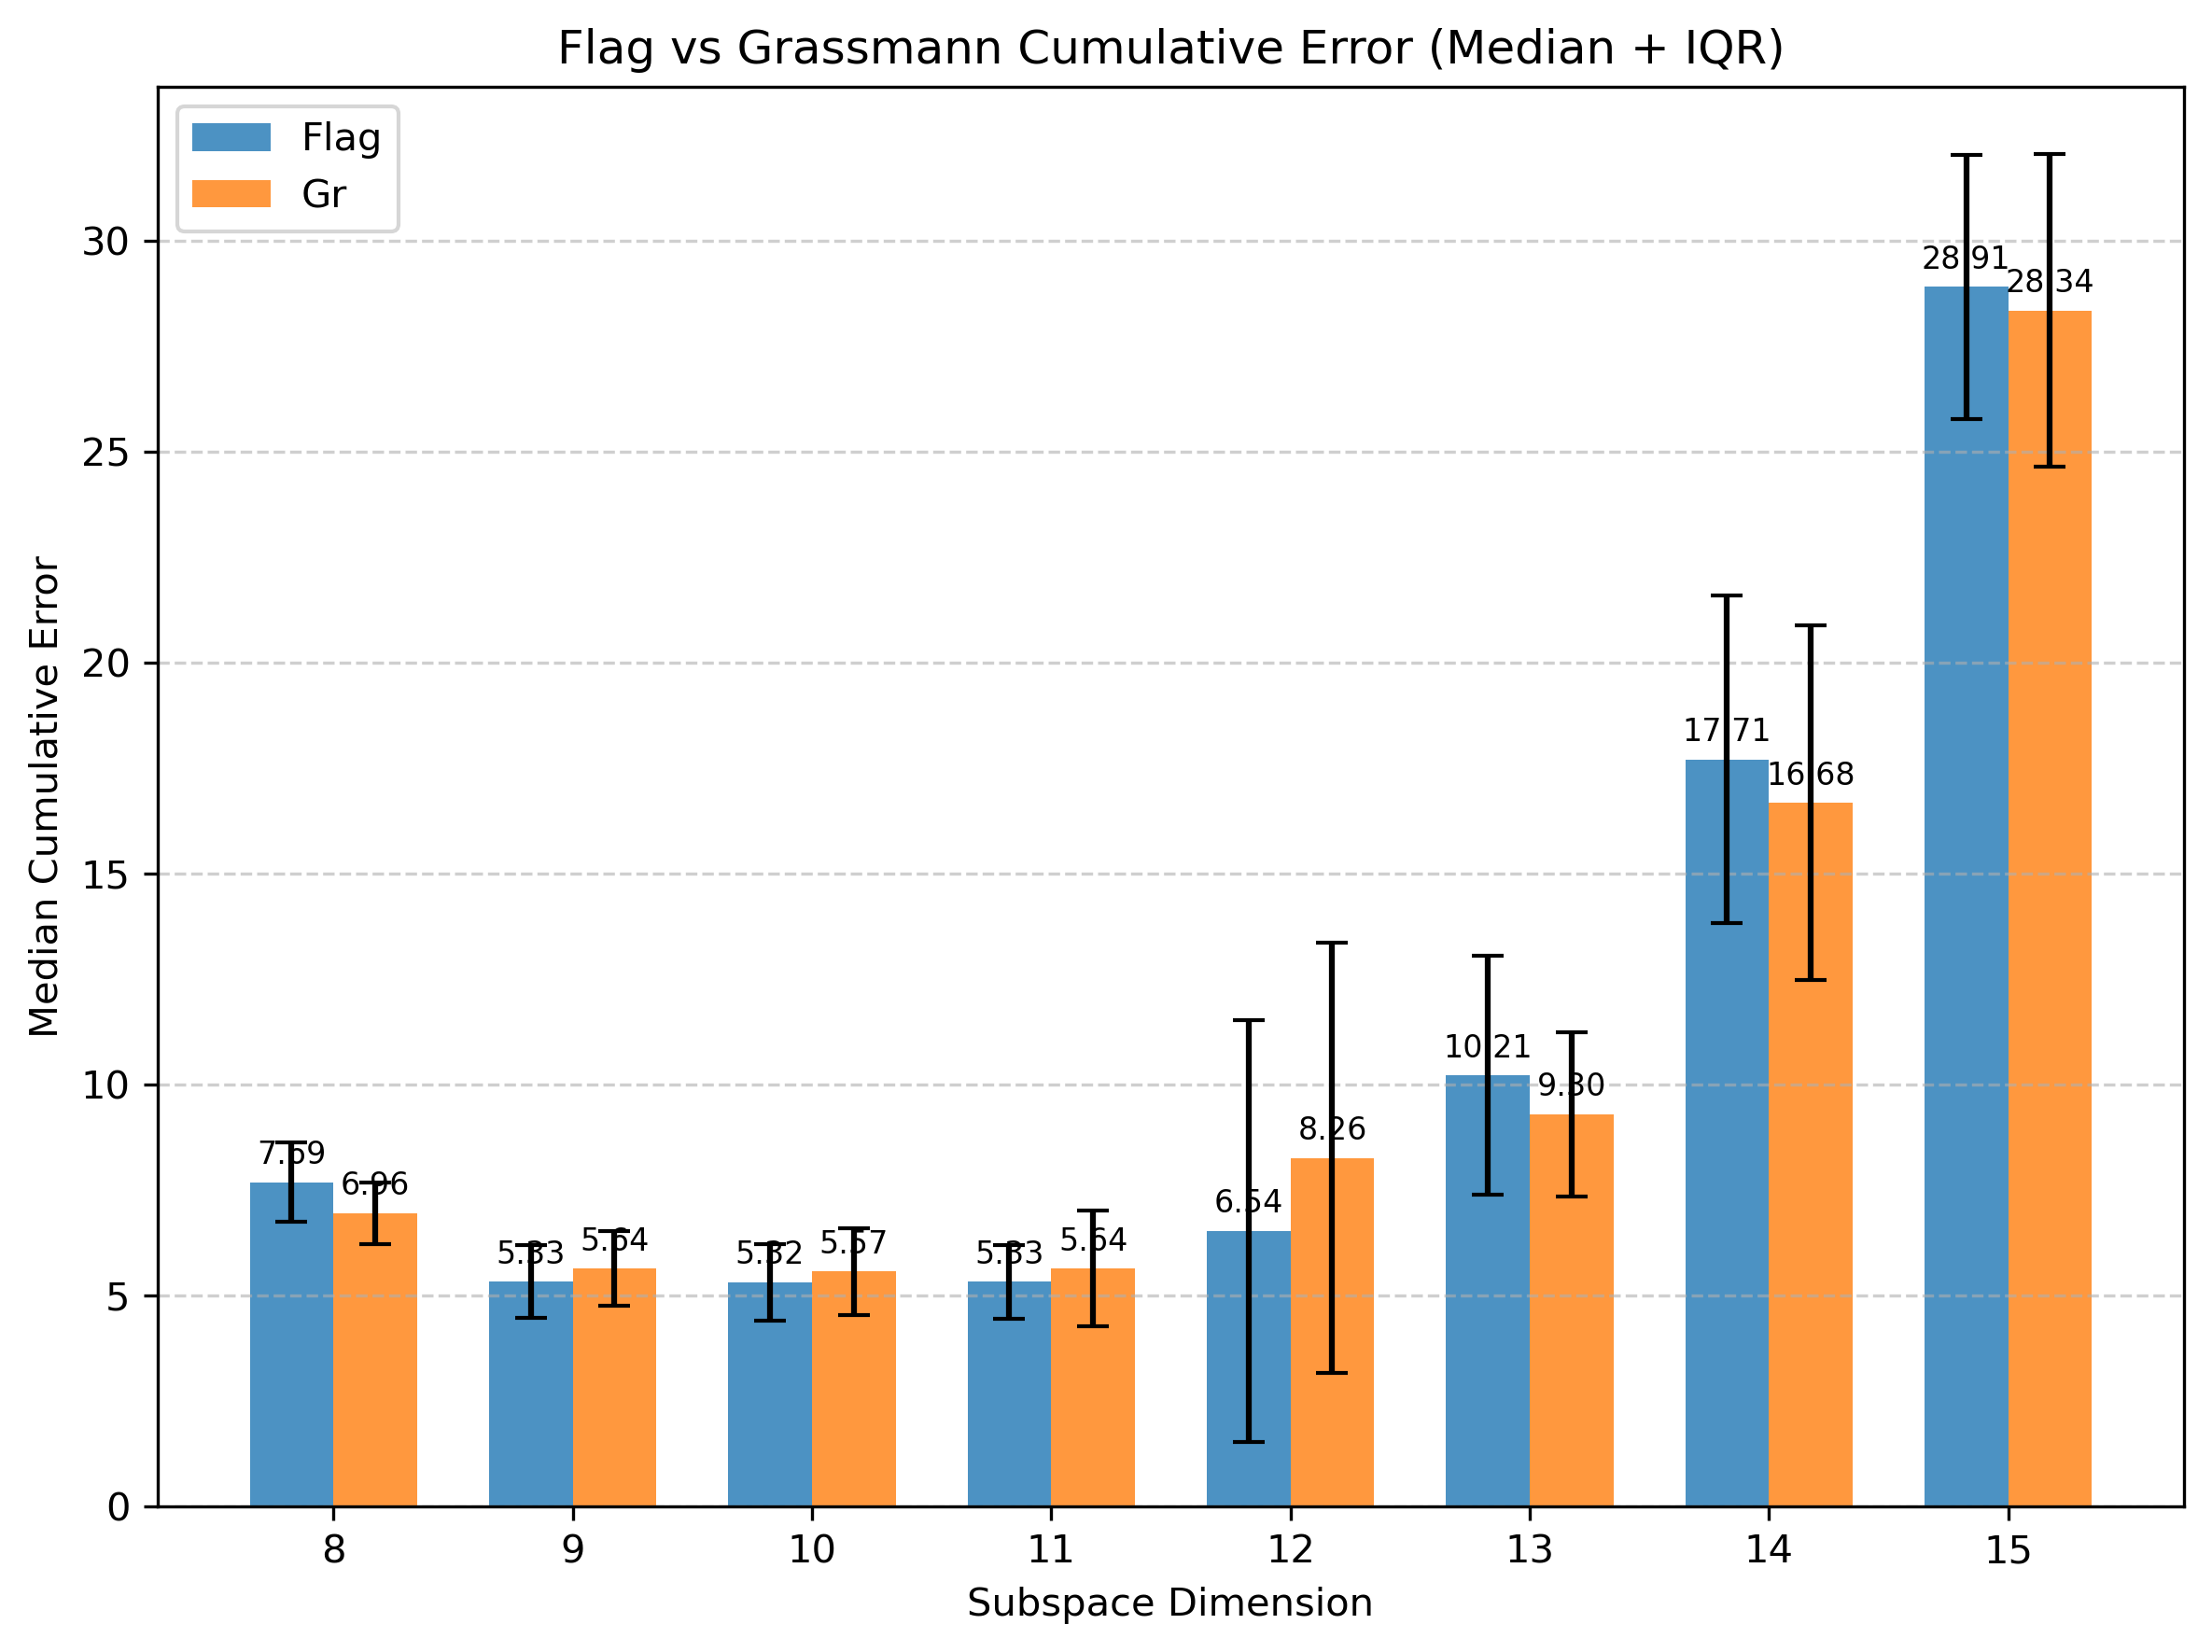

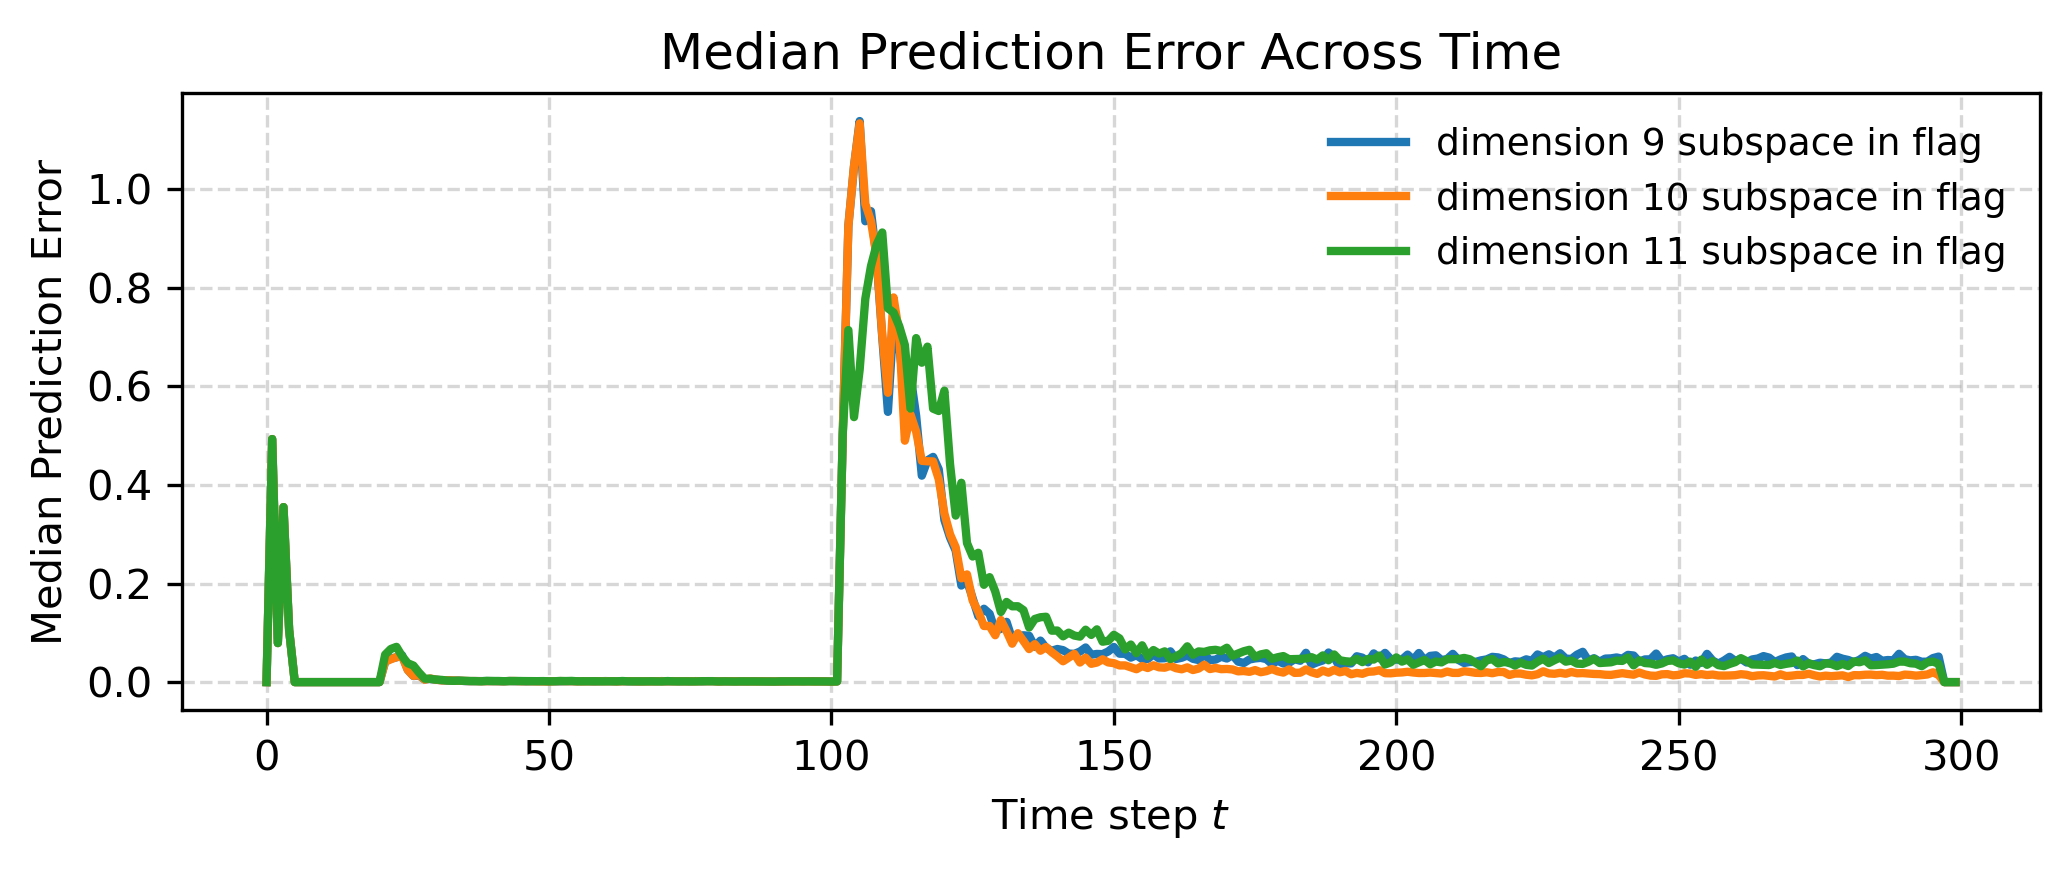

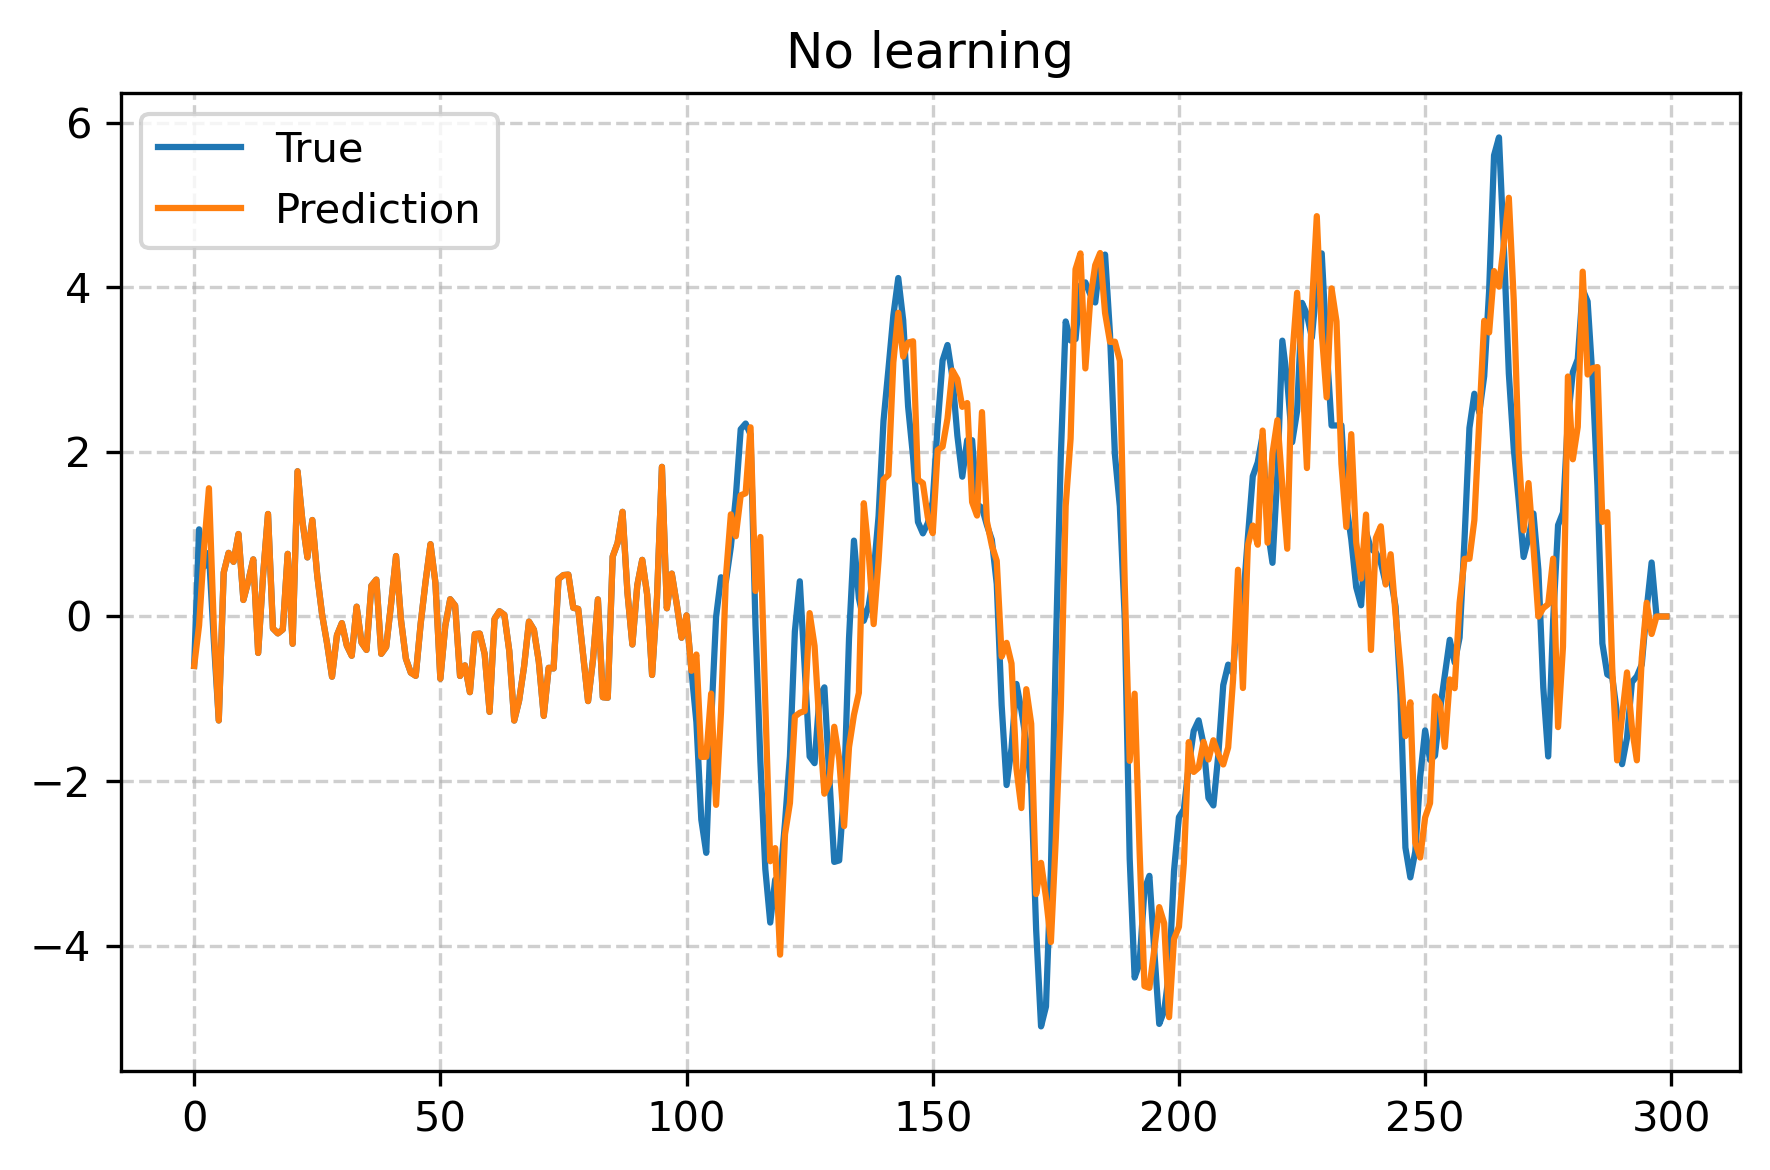

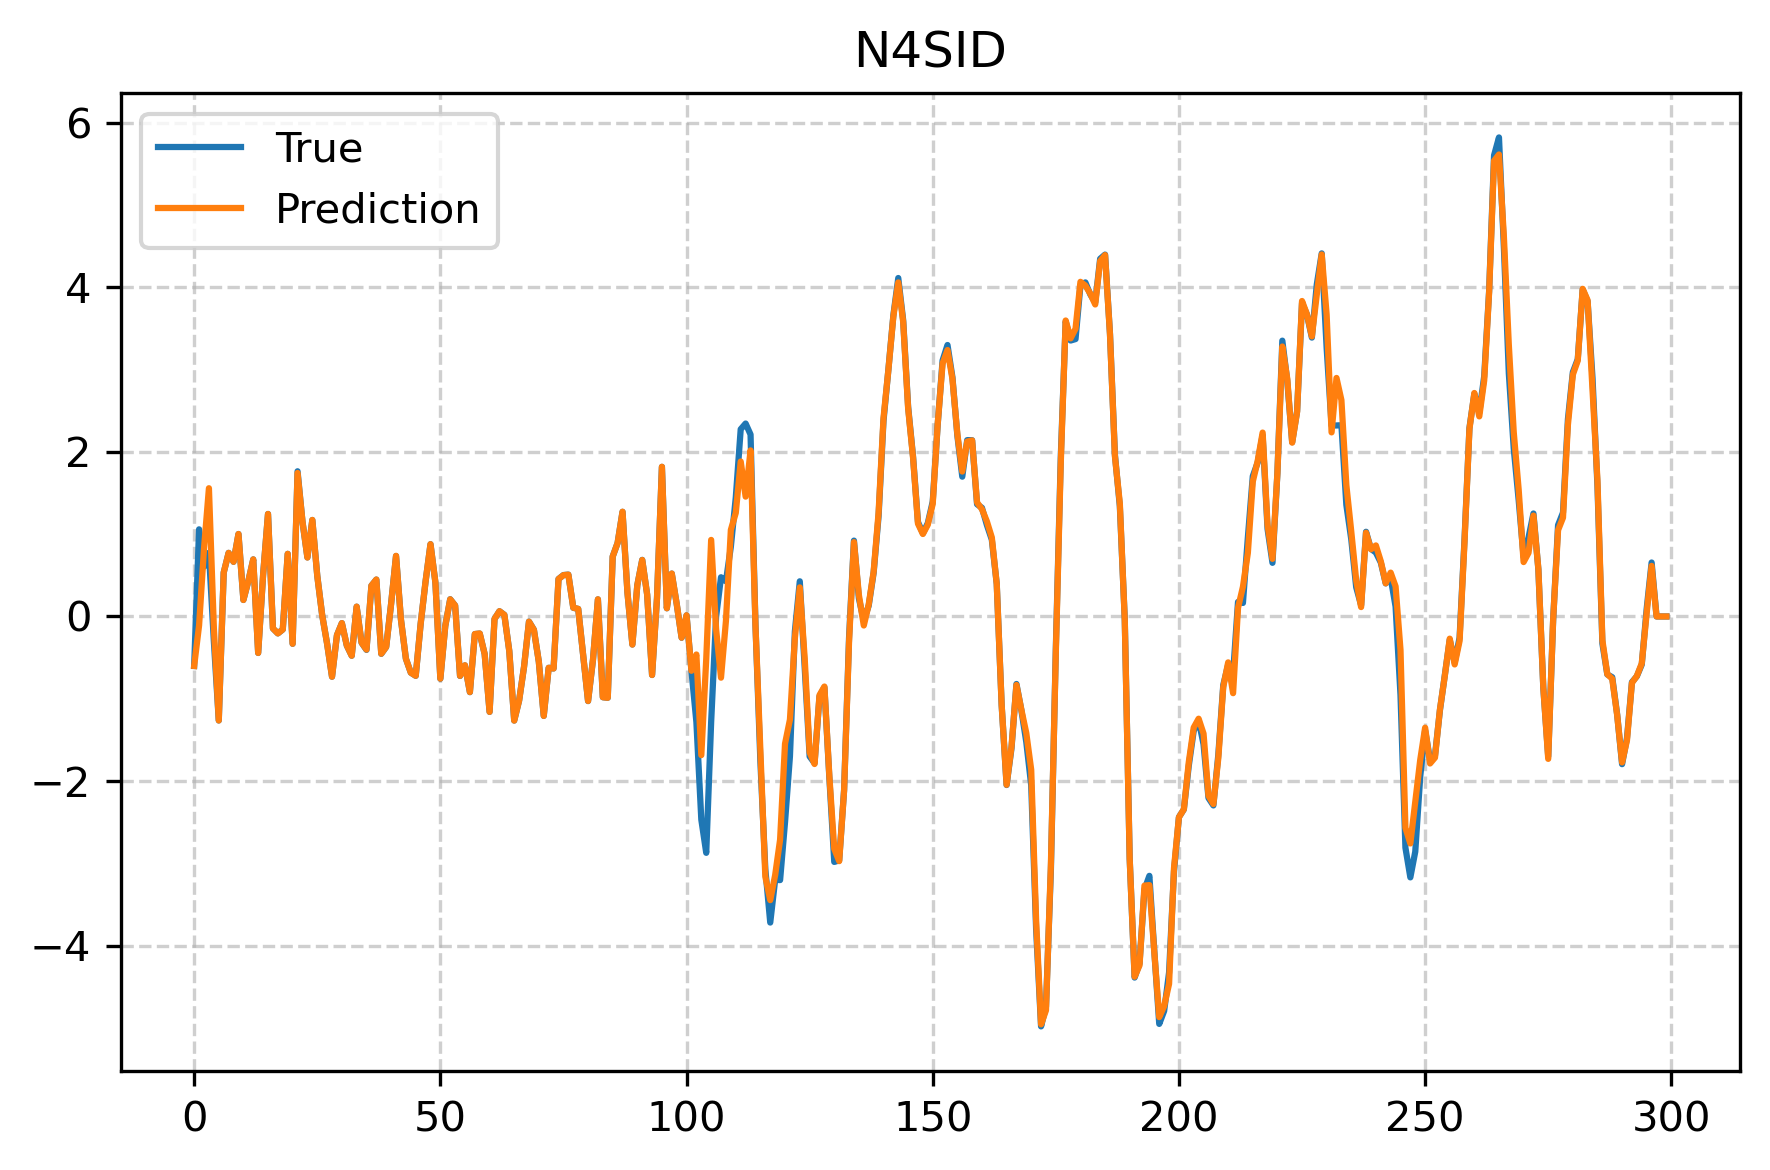

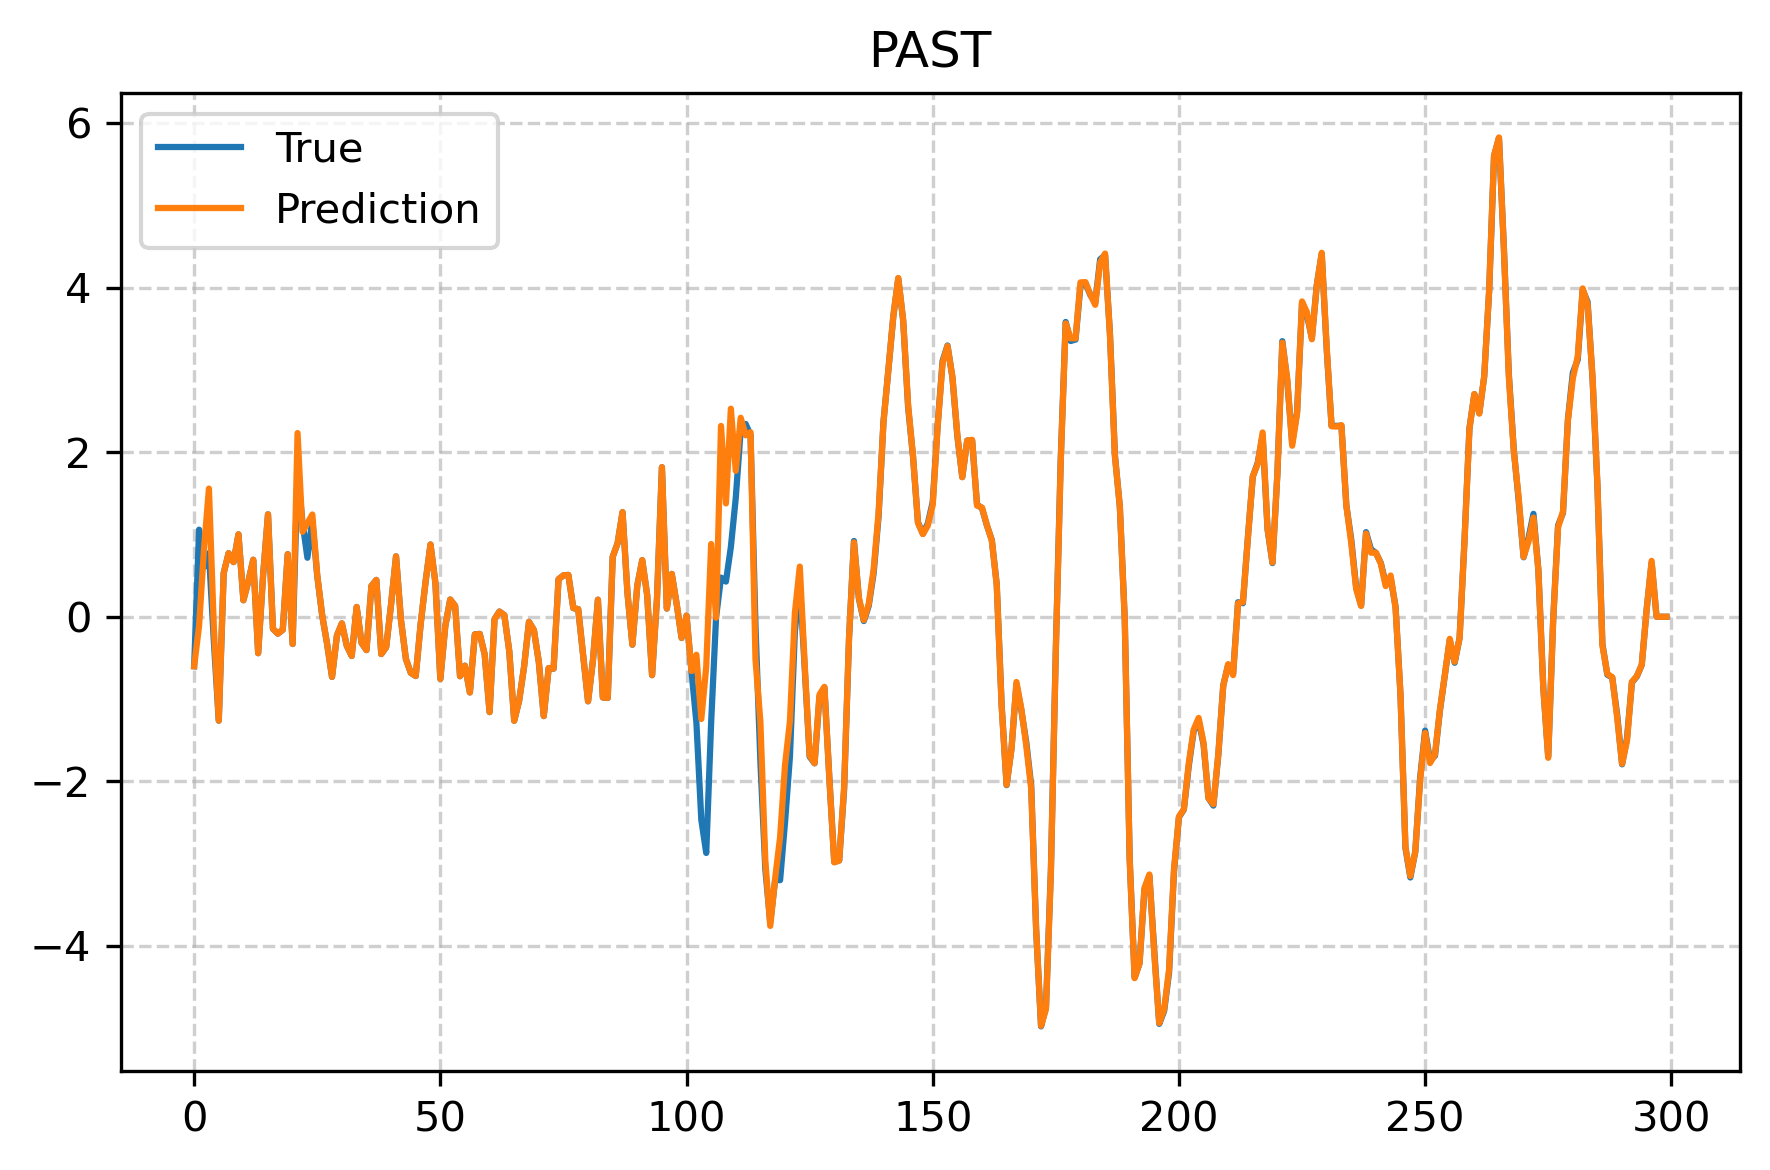

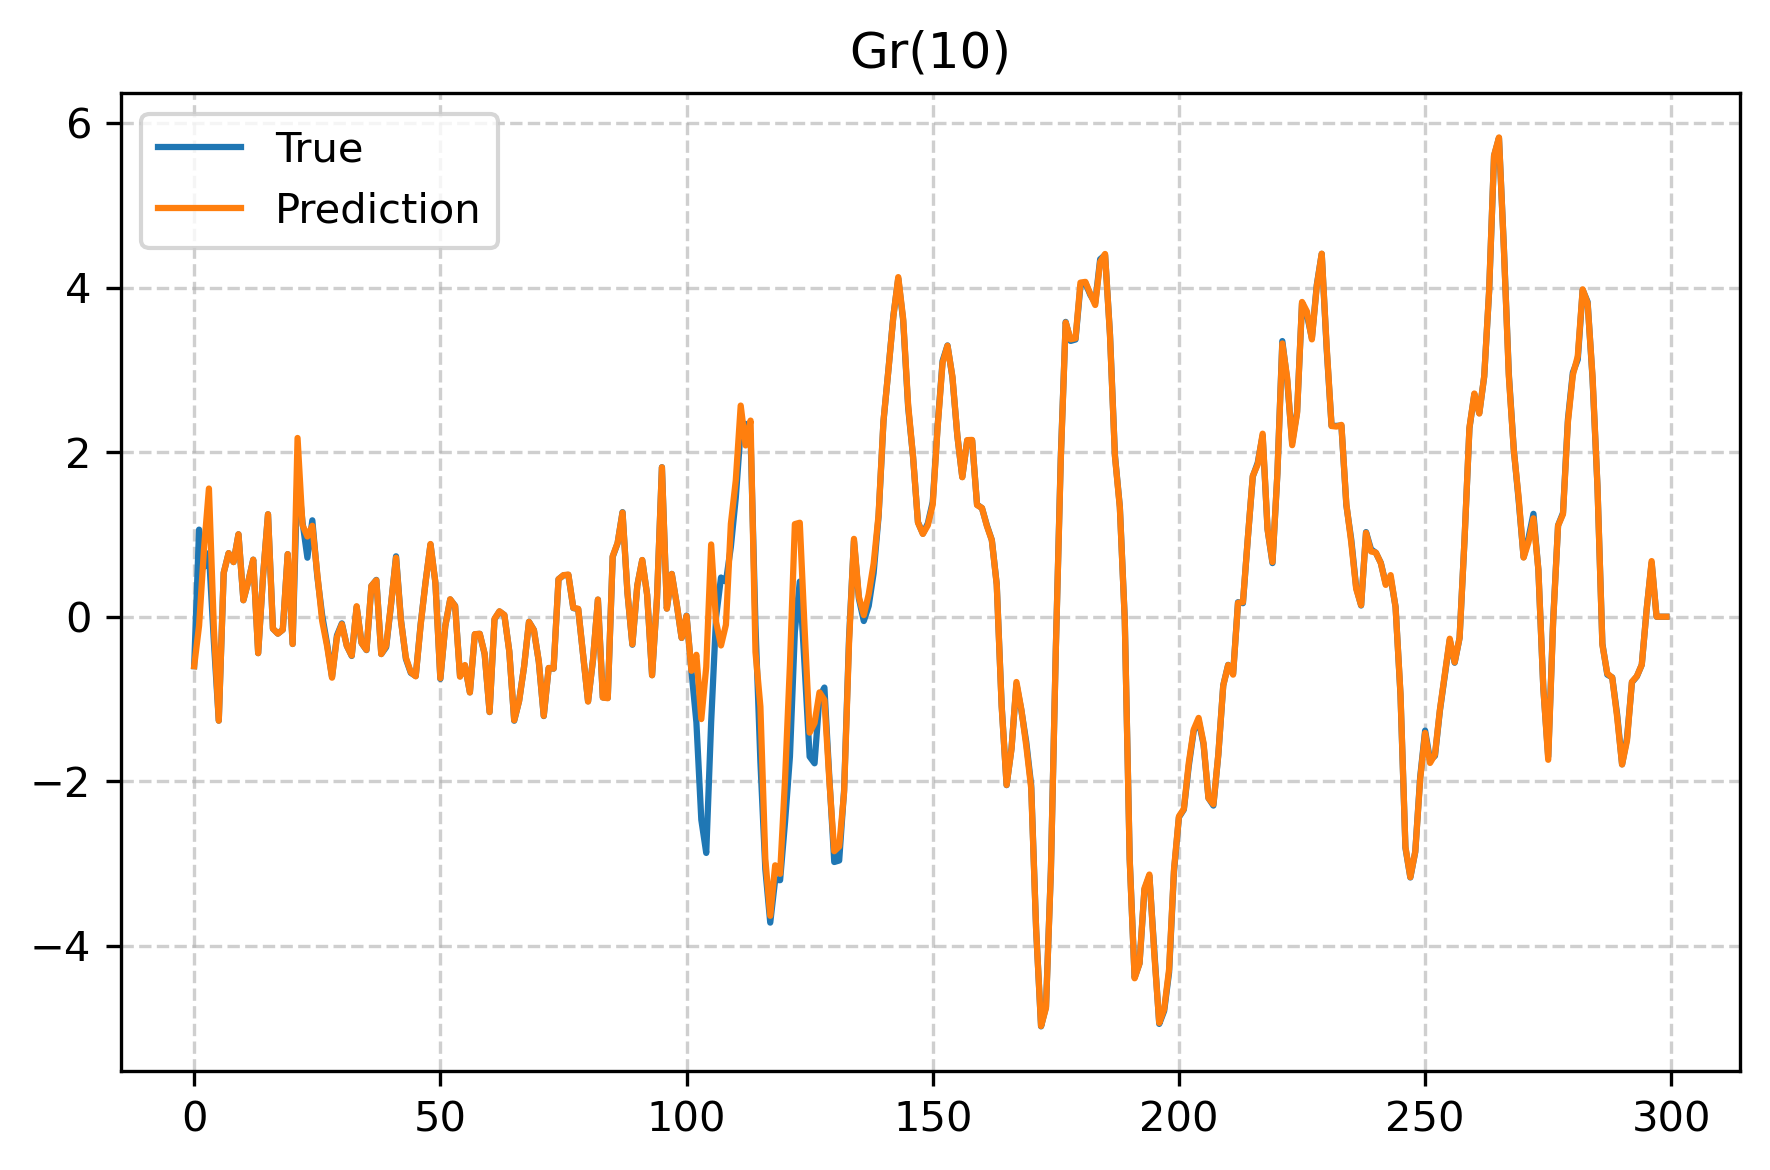

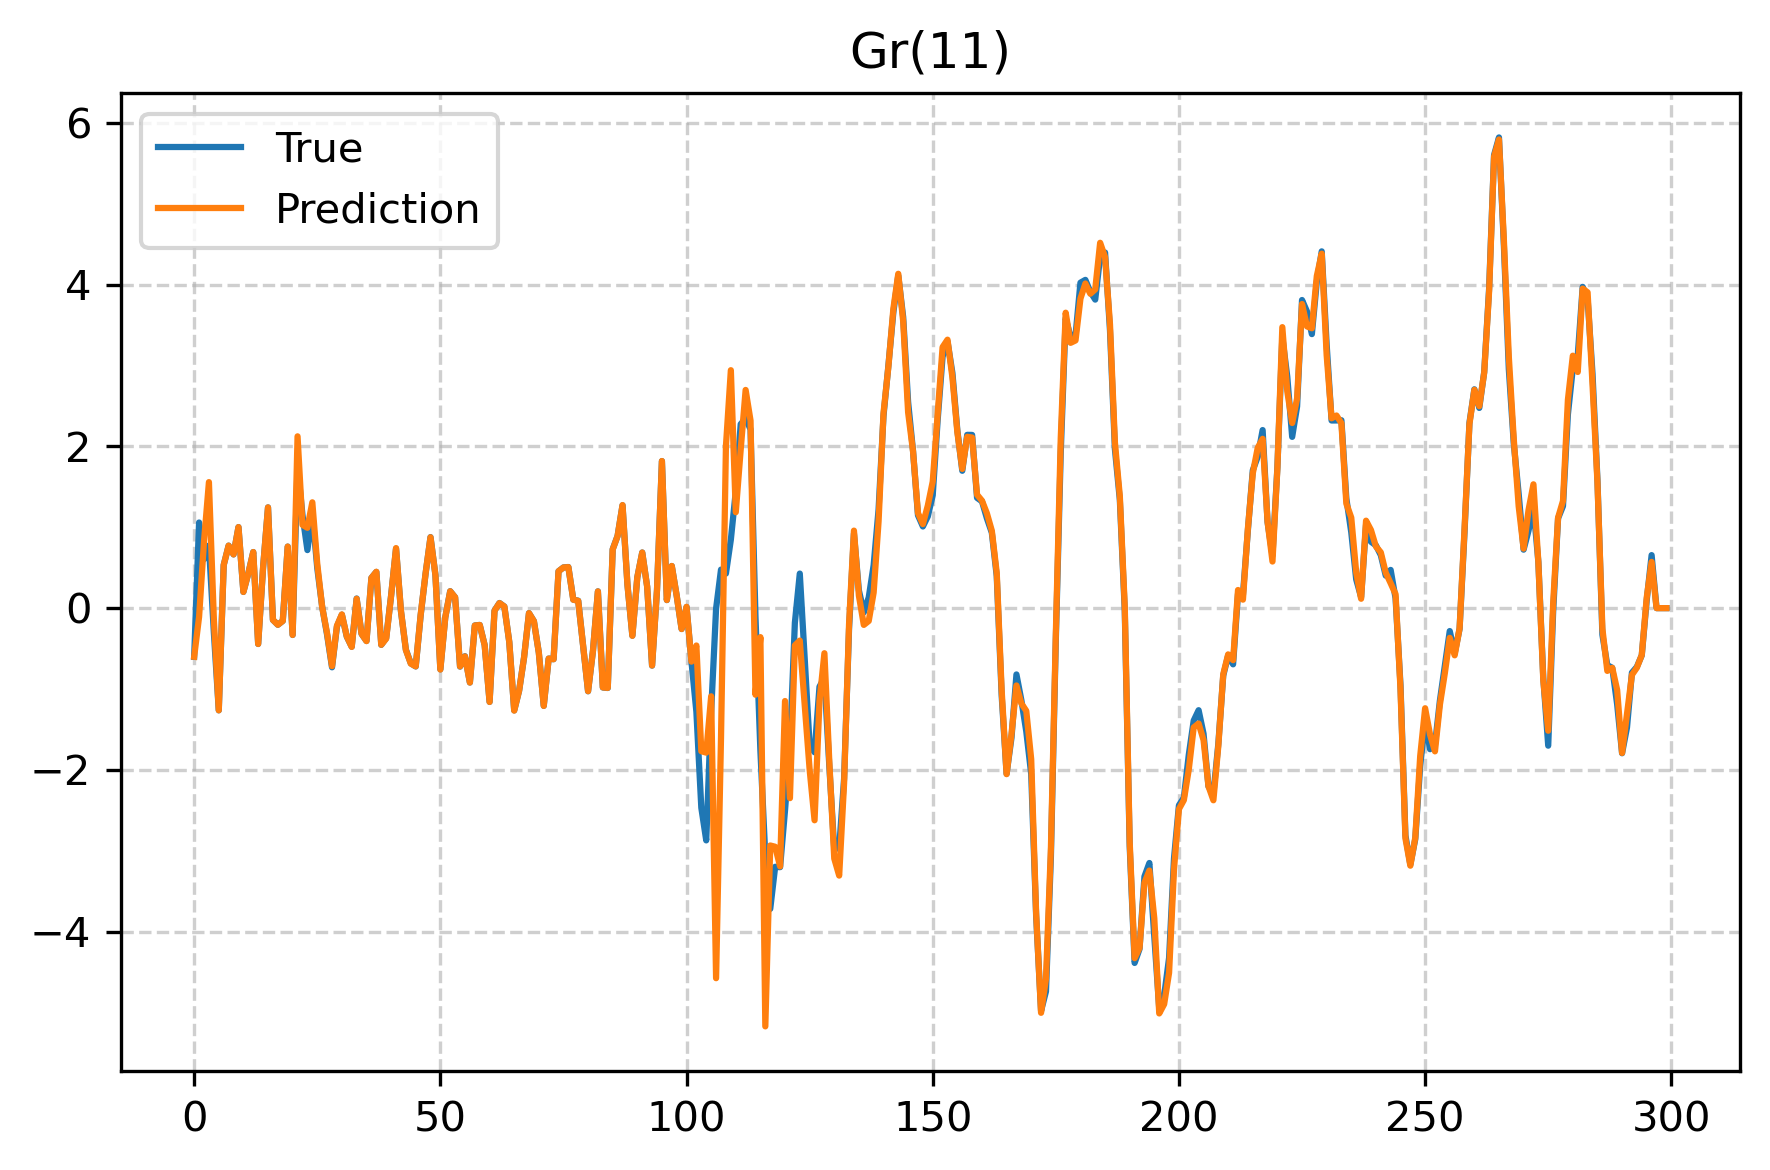

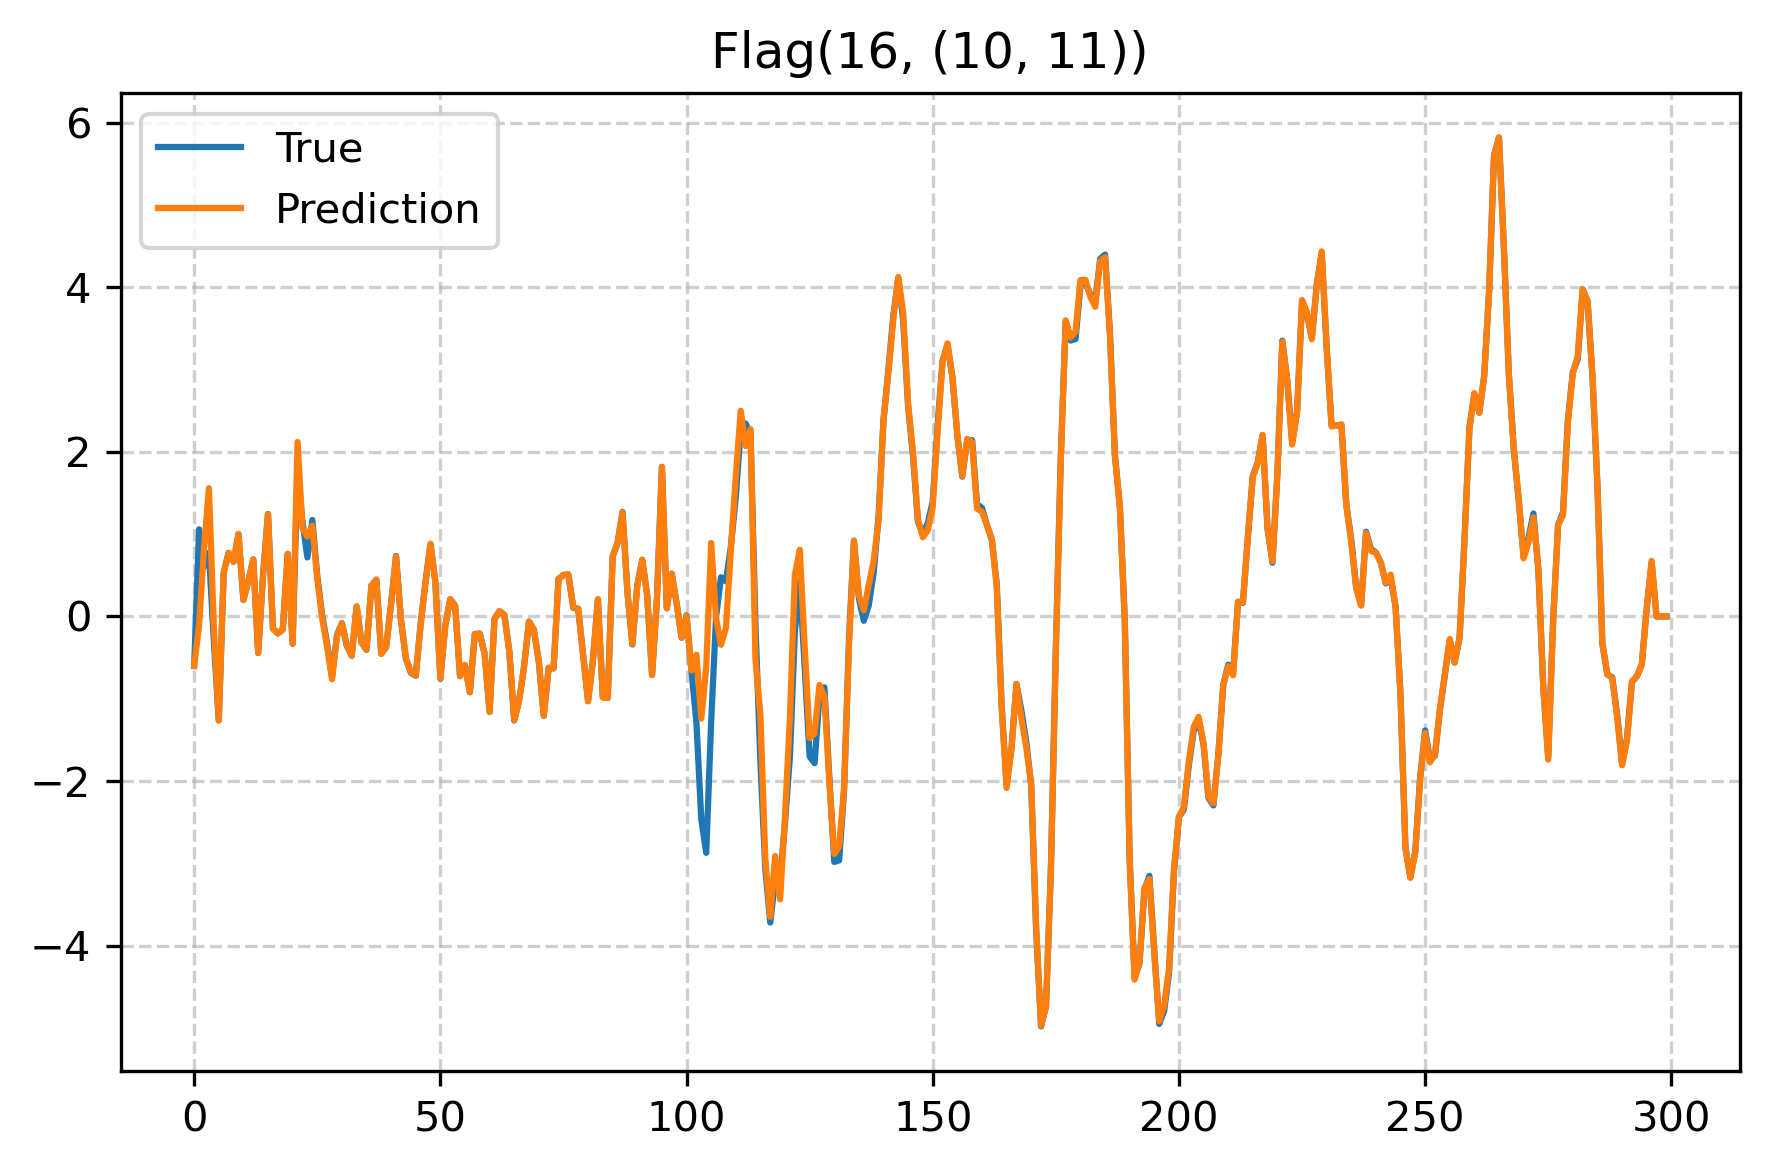

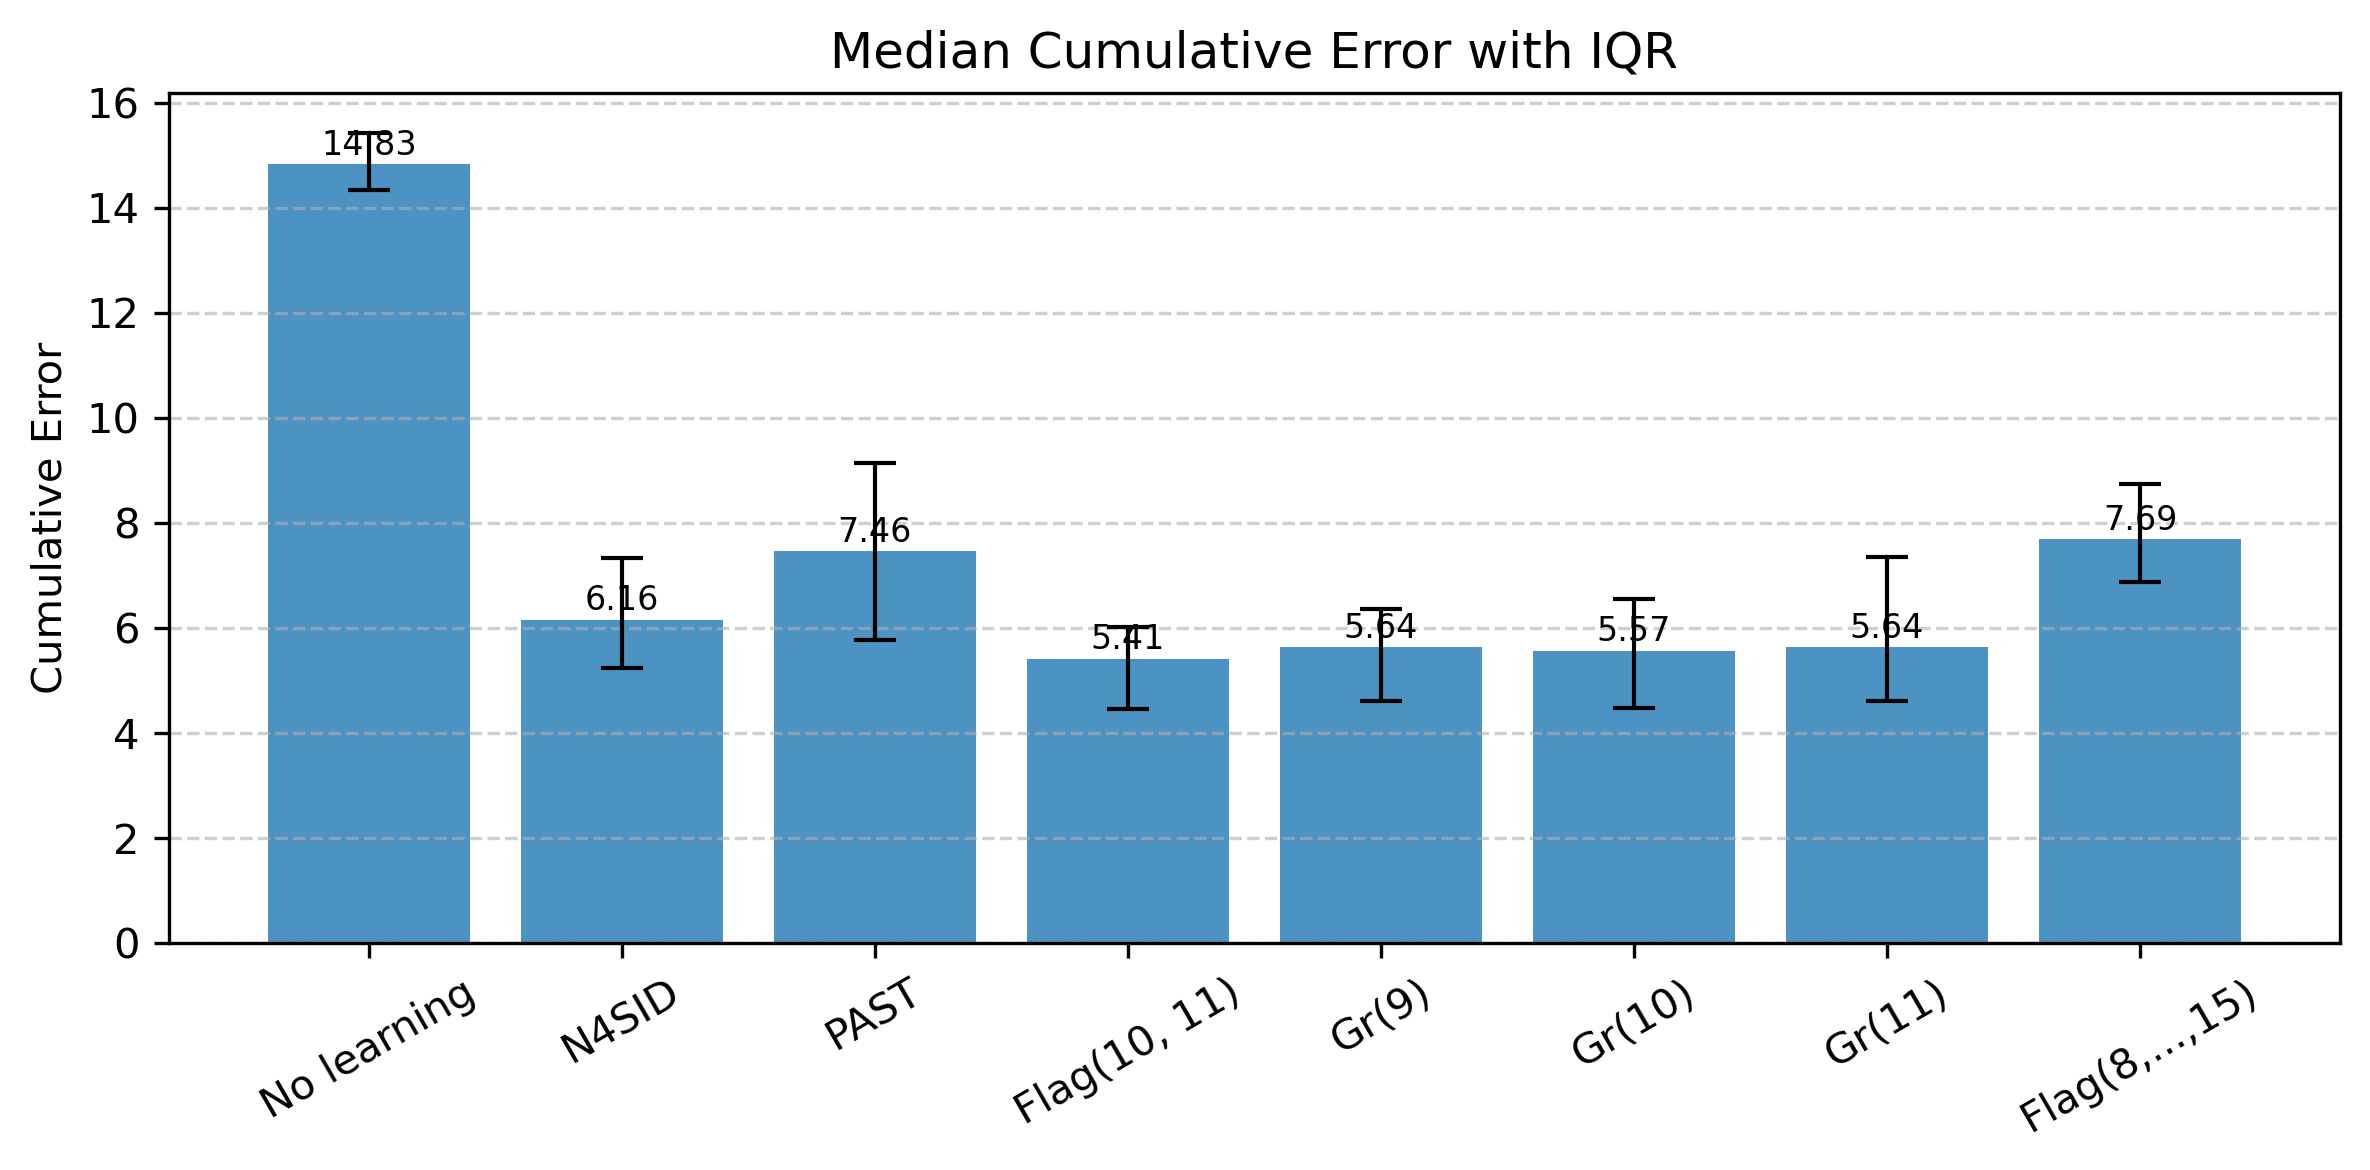

Cleaned data saved to: data_driven_prediction_experiment/cleaned_pred_errors.csv


In [5]:
def run_fl_gr_comparison(num_trials, noise_level, gd_steps):
    save_folder = "data_driven_prediction_experiment"
    os.makedirs(save_folder, exist_ok=True)
    np.random.seed(42)
    num_offline_data = 30
    start_dim = L
    end_dim = (m+n) * L
    signature_fl = tuple(range(start_dim, end_dim))    # e.g., (8, ..., 15)
    # signature_fl = (14,)
    num_models = len(signature_fl)
    
    cum_err_fl_trials = np.zeros((num_trials, num_models))
    cum_err_gr_trials = np.zeros((num_trials, num_models))
    pred_error_trials = np.zeros((num_trials, num_models, T_SIM))

    for trial in range(num_trials):
        noise = noise_level * np.random.randn(n)
        offline_data = get_hankel_data(system1, num_offline_data, noise)
        inputs = np.random.randn(n, T_SIM)
        y_predict_fl, y_true = run_prediction("FRONT-all", offline_data, inputs, noise, signature_fl)
        y_predict_gr = np.zeros((n, T_SIM, end_dim-start_dim))
        for idx, dim in enumerate(signature_fl):
            y_predict_gr[:, :, idx], _ = run_prediction("FRONT", offline_data, inputs, noise, (dim,))

        # ------- compute cumulative prediction error -------
        diff_fl = y_predict_fl - y_true[:, :, None]
        diff_gr = y_predict_gr - y_true[:, :, None]
        pred_error_trials[trial, :, :] = np.linalg.norm(diff_fl, axis=0).T 
        cum_err_fl_trials[trial, :] = np.linalg.norm(diff_fl.reshape(n * T_SIM, num_models), axis=0)
        cum_err_gr_trials[trial, :] = np.linalg.norm(diff_gr.reshape(n * T_SIM, num_models), axis=0)

    med_pred_error_fl = np.median(pred_error_trials, axis=0)
    med_cum_err_fl = np.median(cum_err_fl_trials, axis=0)
    iqr_cum_err_fl = np.percentile(cum_err_fl_trials, 70, axis=0) - np.percentile(cum_err_fl_trials, 30, axis=0)
    med_cum_err_gr = np.median(cum_err_gr_trials, axis=0)
    iqr_cum_err_gr = np.percentile(cum_err_gr_trials, 70, axis=0) - np.percentile(cum_err_gr_trials, 30, axis=0)
    avg_cum_err_fl = cum_err_fl_trials.mean(axis=0)
    std_cum_err_fl = cum_err_fl_trials.std(axis=0)
    avg_cum_err_gr = cum_err_gr_trials.mean(axis=0)
    std_cum_err_gr = cum_err_gr_trials.std(axis=0)
    avg_std_all_err = np.column_stack(
        [list(signature_fl), avg_cum_err_fl, std_cum_err_fl, avg_cum_err_gr, std_cum_err_gr])
    med_iqr_all_err = np.column_stack([
        np.asarray(signature_fl, dtype=int), med_cum_err_fl, iqr_cum_err_fl, med_cum_err_gr, iqr_cum_err_gr])
    save_data(avg_std_all_err, f"flag_vs_gr_avg", save_folder)
    save_data(med_iqr_all_err, f"flag_vs_gr_median", save_folder)
    save_data(med_pred_error_fl, f"pred_error_flag_subspace", save_folder)
    
    def plot_pred_errors_median():
        fig, ax = plt.subplots(figsize=(7, 3))
        time = np.arange(T_SIM)
        selected_dims = [9, 10, 11]
        selected_idx = [signature_fl.index(d) for d in selected_dims if d in signature_fl]
        for idx in selected_idx:
            ax.plot(time, med_pred_error_fl[idx, :], linewidth=2, 
                    label=f"dimension {signature_fl[idx]} subspace in flag")

        ax.set_xlabel("Time step $t$")
        ax.set_ylabel("Median Prediction Error")
        ax.set_title("Median Prediction Error Across Time")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(frameon=False, fontsize=9)
        plt.tight_layout()
        plt.show()
        
    def plot_flag_vs_gr():
        x = np.arange(num_models)   
        dims_as_labels = [str(d) for d in signature_fl]
        width = 0.35                     
        fig, ax = plt.subplots(figsize=(8, 6))
    
        # Bars with median, error bars = IQR/2 (symmetric)
        bars_fl = ax.bar(x - width/2, med_cum_err_fl, width, 
                         yerr=iqr_cum_err_fl/2, capsize=4, label='Flag', alpha=0.8)
        bars_gr = ax.bar(x + width/2, med_cum_err_gr, width, 
                         yerr=iqr_cum_err_gr/2, capsize=4, label='Gr', alpha=0.8)
    
        # Annotate numbers above bars
        for bar in bars_fl:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3), 
                        textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
        for bar in bars_gr:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3),
                        textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
        ax.set_xticks(x)
        ax.set_xticklabels(dims_as_labels)
        ax.set_xlabel("Subspace Dimension")
        ax.set_ylabel("Median Cumulative Error")
        ax.set_title("Flag vs Grassmann Cumulative Error (Median + IQR)")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.6)
    
        plt.tight_layout()
        plt.show()
    
    plot_flag_vs_gr()
    plot_pred_errors_median()
    
    return None

def run_alg_comparison(signature, num_trials, noise_level):
    save_folder = "data_driven_prediction_experiment"
    os.makedirs(save_folder, exist_ok=True)
    np.random.seed(42)
    model_specs = [
        ("No learning",       {"algorithm": "nonlearning",      "signature": None}),
        ("N4SID",             {"algorithm": "N4SID",            "signature": None}),
        ("PAST",              {"algorithm": "PAST",             "signature": None}),
        (f"Flag{signature}",  {"algorithm": "FRONT",            "signature": signature}),
        ("Gr(9)",             {"algorithm": "FRONT",            "signature": (9,)}),
        ("Gr(10)",            {"algorithm": "FRONT",            "signature": (10,)}),
        ("Gr(11)",            {"algorithm": "FRONT",            "signature": (11,)}),
        ("Flag(8,...,15)",    {"algorithm": "FRONT",            "signature": tuple(range(8, 16))}),
    ]
    model_names = [name for name, _ in model_specs]
    num_models  = len(model_specs)
    cum_errors = np.zeros((num_trials, num_models), dtype=float)
    pred_errors = np.zeros((num_trials, num_models, T_SIM), dtype=float)
    def cum_error(y_pred, y_true):
        return float(np.linalg.norm(y_pred - y_true))

    last_preds = {}    # store trajectories from last trial for plot
    num_offline_data = 30
    for t in range(num_trials):
        noise = noise_level * np.random.randn(n)
        offline_data = get_hankel_data(system1, num_offline_data, noise)
        inputs = np.random.randn(n, T_SIM)

        name0, spec0 = model_specs[0]
        y_nl, y_true = run_prediction("nonlearning", offline_data, inputs, noise)
        pred_errors[t, 0, :] = np.linalg.norm(y_nl - y_true, axis=0)
        cum_errors[t, 0] = cum_error(y_nl, y_true)
        if t == num_trials - 1:
            last_preds[name0] = y_nl
            y_true_last = y_true
            save_data(y_nl.T, f"y_pred_nl", save_folder)
            save_data(y_true.T, f"y_true", save_folder)
            
        for j in range(1, num_models):
            name, spec = model_specs[j]
            y_pred, _ = run_prediction(spec["algorithm"], offline_data, inputs, noise, spec["signature"])
            pred_errors[t, j, :] = np.linalg.norm(y_pred - y_true, axis=0)
            cum_errors[t, j] = cum_error(y_pred, y_true)
            if t == num_trials - 1: 
                last_preds[name] = y_pred
                save_data(y_pred.T, f"y_pred_{name}", save_folder)

    # ---------------- compute mean and median ------------------
    avg_pred_errors = pred_errors.mean(axis=0)
    std_pred_errors = pred_errors.std(axis=0)
    med_cum_errors = np.median(cum_errors, axis=0)
    q30_cum_errors = np.percentile(cum_errors, 30, axis=0)
    q70_cum_errors = np.percentile(cum_errors, 70, axis=0)
    med_pct_cum_errors = np.column_stack([med_cum_errors, q30_cum_errors, q70_cum_errors])
    save_data(med_pct_cum_errors, f"med_pct_cum_errors", save_folder)
    
    avg_cum_errors = cum_errors.mean(axis=0)
    std_cum_errors = cum_errors.std(axis=0)
    avg_std_cum_errors = np.column_stack([avg_cum_errors, std_cum_errors])
    save_data(avg_std_cum_errors, f"avg_std_cum_errors", save_folder)

    # ---------------- save prediction errors (not cumulative) ----------------
    pred_error_data = {"t": np.arange(T_SIM)}
    for j, name in enumerate(model_names):
        pred_error_data[f"med_{name}"] = np.median(pred_errors[:, j, :], axis=0)
        pred_error_data[f"q30_{name}"] = np.percentile(pred_errors[:, j, :], 30, axis=0)
        pred_error_data[f"q70_{name}"] = np.percentile(pred_errors[:, j, :], 70, axis=0)
        
    pred_error_df = pd.DataFrame(pred_error_data)
    pred_error_df.to_csv(f"{save_folder}/pred_errors.csv", index=False)

    # ---------------- utils: plot median and mean ------------------
    def plot_cum_errors_median():
        x = np.arange(num_models)
        fig, ax = plt.subplots(figsize=(8,4))
        bars = ax.bar(x, med_cum_errors, alpha=0.8)
        # error bars: 25th and 75th percentiles around the median
        yerr_lower = med_cum_errors - q30_cum_errors
        yerr_upper = q70_cum_errors - med_cum_errors
        yerr = np.vstack([yerr_lower, yerr_upper])
    
        ax.errorbar(x, med_cum_errors, yerr=yerr, fmt='none',
                    ecolor='black', capsize=5, elinewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=30)
        ax.set_ylabel("Cumulative Error")
        ax.set_title("Median Cumulative Error with IQR")
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        for rect, val in zip(bars, med_cum_errors):
            ax.text(rect.get_x() + rect.get_width()/2, 
                    rect.get_height() + 0.05,
                    f"{val:.2f}", 
                    ha='center', va='bottom', fontsize=8)
    
        plt.tight_layout()
        plt.show()

    def plot_cum_errors_mean():
        x = np.arange(num_models)
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(x, avg_cum_errors, alpha=0.8)
    
        yerr_lower = np.minimum(std_cum_errors, avg_cum_errors)
        yerr_upper = std_cum_errors
        yerr = np.vstack([yerr_lower, yerr_upper])
        ax.errorbar(
            x, avg_cum_errors, yerr=yerr, fmt='none',
            ecolor='black', capsize=5, elinewidth=1
        )
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=30)
        ax.set_ylabel("Cumulative Error")
        ax.set_title("Mean Cumulative Error with Std")
        ax.grid(axis="y", linestyle="--", alpha=0.6)
    
        for rect, val in zip(bars, avg_cum_errors):
            ax.text(
                rect.get_x() + rect.get_width()/2,
                rect.get_height() + 0.05,
                f"{val:.2f}",
                ha='center', va='bottom', fontsize=8
            )
    
        plt.tight_layout()
        plt.show()
        
    # ---------------- plot trajectories from last tiral --------------------
    plot_trajectories(y_true_last, last_preds["No learning"], f"No learning")
    plot_trajectories(y_true_last, last_preds["N4SID"], f"N4SID")
    plot_trajectories(y_true_last, last_preds["PAST"], f"PAST")
    plot_trajectories(y_true_last, last_preds["Gr(10)"], f"Gr(10)")
    plot_trajectories(y_true_last, last_preds["Gr(11)"], f"Gr(11)")
    plot_trajectories(y_true_last, last_preds[f"Flag{signature}"], f"Flag(16, {signature})")
    
    plot_cum_errors_median()
    # plot_cum_errors_mean()
        
    return None

def process_data():
    """
    trim pred_errors.csv since we only predict T_SIM - T_F = 296 outputs
    """
    file_path = "data_driven_prediction_experiment/pred_errors.csv"
    df = pd.read_csv(file_path, header=None)
    df = df.iloc[:T_SIM - T_F, :]
    save_path = "data_driven_prediction_experiment/cleaned_pred_errors.csv"
    df.to_csv(save_path, index=False, header=False)
    print(f"Cleaned data saved to: {save_path}")

def main():
    run_fl_gr_comparison(100, 1e-3, 5)
    run_alg_comparison((10, 11), 100, 1e-3)
    process_data()

main()